# 04 - Visualisations des KPIs Enedis

Ce notebook lit les tables Gold produites par le notebook 03
et genere des visualisations matplotlib pour chaque KPI.

Visualisations produites :
- KPI 1 : Graphique en barres groupées - Consommation par région et par année
- KPI 2 : Courbe avec marqueurs - évolution nationale et variation YoY
- KPI 3 : Graphique en barres horizontales - Répartition par catégorie
- KPI 4 : Graphique en barres horizontales - Classement des régions


Remarque : Les visualisations Matplotlib que j’ai produites sont uniquement destinées à la démonstration. En production, les tables Gold seraient directement connectées à Power BI, Tableau ou tout autre outil de visualisation via le connecteur Databricks, sans passer par une génération de graphiques côté Python.

## Configuration et imports

In [0]:
# Imports des bibliotheques de visualisation 

import matplotlib.pyplot as plt        
import matplotlib.ticker as mticker    # Formateurs d'axes 
import numpy as np                     

# Configuration globale du style des graphiques
plt.rcParams["figure.figsize"]  = (14, 6)   # Taille par defaut de chaque figure (largeur x hauteur en pouces)
plt.rcParams["axes.spines.top"]    = False  # Suppression du bord superieur du graphique 
plt.rcParams["axes.spines.right"]  = False  # Suppression du bord droit
plt.rcParams["axes.grid"]          = True   # Grille activée par defaut pour faciliter la lecture
plt.rcParams["grid.alpha"]         = 0.3    # Grille semi-transparente
plt.rcParams["font.size"]          = 11     # Taille de police par defaut

# Palette de couleurs 
COULEUR_2023 = "#003189"   # Bleu fonce 
COULEUR_2024 = "#0070C0"   # Bleu moyen
COULEUR_2025 = "#00AEEF"   # Bleu clair

print("Configuration visualisations chargée")

Configuration visualisations chargée


## Chargement des tables Gold

In [0]:
# Lecture des 4 tables Gold depuis le catalogue Databricks
# Je les les convertie en Pandas pour les utiliser avec matplotlib car matplotlib ne travaille pas directement avec les DataFrames Spark

df_region    = spark.read.table("kpi_conso_par_region").toPandas()
df_tendance  = spark.read.table("kpi_tendance_nationale").toPandas()
df_categorie = spark.read.table("kpi_categorie_distribution").toPandas()
df_top       = spark.read.table("kpi_top_regions").toPandas()

print(f"kpi_conso_par_region      : {len(df_region)} lignes")
print(f"kpi_tendance_nationale    : {len(df_tendance)} lignes")
print(f"kpi_categorie_distribution: {len(df_categorie)} lignes")
print(f"kpi_top_regions           : {len(df_top)} lignes")
print("Tables Gold chargées en Pandas")

kpi_conso_par_region      : 36 lignes
kpi_tendance_nationale    : 3 lignes
kpi_categorie_distribution: 4 lignes
kpi_top_regions           : 12 lignes
Tables Gold chargées en Pandas


## Visualisation KPI 1 - Consommation par région et par année

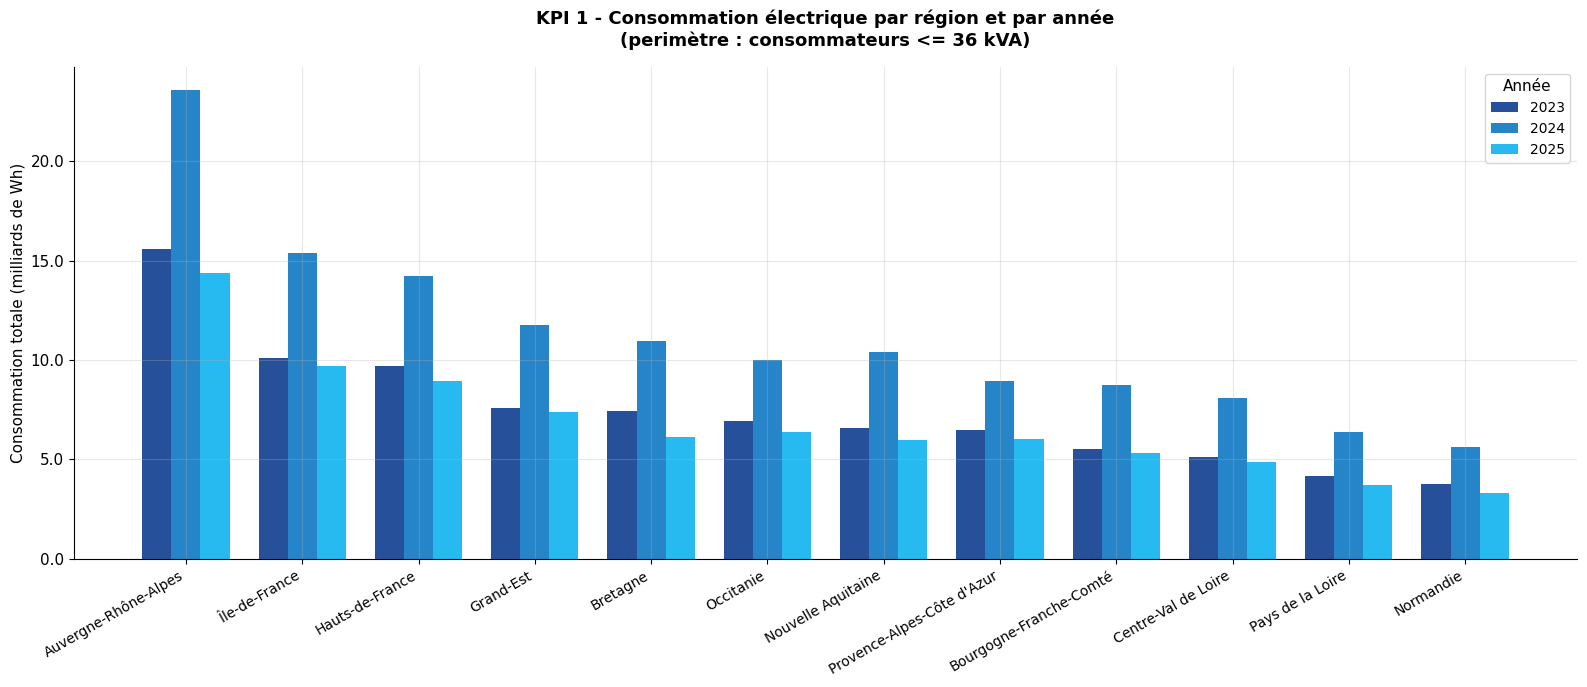

In [0]:
# # Préparation des données : on pivote le DataFrame pour obtenir une colonne par année
# pivot_table() cree un tableau croise : index = région, colonnes = années, valeurs = conso_totale

df_pivot = df_region.pivot_table(
    index="region",           # Une ligne par region
    columns="annee",          # Une colonne par année
    values="conso_totale_mwh" # Valeur à afficher
)

df_pivot = df_pivot / 1_000_000_000                     # Conversion des valeurs en milliards de Wh pour une meilleure lisibilite sur l'axe Y

# Tri des regions par consommation totale decroissante pour un classement lisible

df_pivot["total"] = df_pivot.sum(axis=1)   # Somme des 3 années pour chaque region

df_pivot = df_pivot.sort_values("total", ascending=False)  # Tri décroissant

df_pivot = df_pivot.drop(columns="total")  # Suppression de la colonne de tri

# Construction du graphique en barres groupees 

annees     = df_pivot.columns.tolist()   # Liste des années disponibles 
n_regions  = len(df_pivot)               # Nombre de regions
n_annees   = len(annees)                 # Nombre d'annees

# Calcul des positions des barres sur l'axe X

x         = np.arange(n_regions)                     # np.arange cree un tableau de positions entières (une par region)
largeur   = 0.25                                     # Largeur de chaque barre (3 barres cote a cote = 0.75 total)
couleurs  = [COULEUR_2023, COULEUR_2024, COULEUR_2025]

fig, ax = plt.subplots(figsize=(16, 7))  # Création de la figure et de l'axe

for i, (annee, couleur) in enumerate(zip(annees, couleurs)):                               # Calcul du decalage horizontal pour chaque groupe d'annees. 
                                                                                           
    decalage = (i - n_annees / 2 + 0.5) * largeur                                          # (i - n_annees/2 + 0.5) centre les barres autour de la position de la region

    barres = ax.bar(
        x + decalage,               # Position horizontale de chaque barre
        df_pivot[annee],            # Hauteur des barres (consommation)
        width=largeur,              # Largeur de chaque barre
        color=couleur,              # Couleur selon l'année
        label=str(annee),           # Légende
        alpha=0.85                  # Légère transparence
    )

# Mise en forme des axes 

ax.set_xticks(x)                                                                    # Position des etiquettes sur l'axe X
ax.set_xticklabels(df_pivot.index, rotation=30, ha="right", fontsize=10)            # Noms des regions inclines
ax.set_ylabel("Consommation totale (milliards de Wh)", fontsize=11)
ax.set_xlabel("")
ax.set_title(
    "KPI 1 - Consommation électrique par région et par année\n(perimètre : consommateurs <= 36 kVA)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(title="Année", fontsize=10)

# Formateur de l'axe Y : affiche les nombres avec 1 decimale (ex: 14.4)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))

plt.tight_layout()   # Ajustement automatique des marges pour éviter les coupures
plt.show()          

### Interprétation 

A travers ce graphique, nous remarquons que la région Auvergne–Rhône-Alpes se distingue nettement avec une consommation 2024 d’environ 23 milliards de Wh, soit plus du double de l’Île‑de‑France, qui occupe la deuxième place. Cet écart s’explique par la forte présence d’industries électro‑intensives dans la région (chimie, métallurgie, plasturgie), historiquement consommatrices d’électricité.

La barre 2024 (bleu moyen) apparaît systématiquement comme la plus élevée dans toutes les régions. Cette hausse uniforme n’est pas uniquement d’origine climatique : elle provient aussi d’une granularité temporelle plus fine dans les données 2024 (656 enregistrements par région, contre 492 en 2023 et 2025), ce qui entraîne mécaniquement des agrégations plus élevées.

Certaines régions notamment Bretagne, Occitanie et Nouvelle‑Aquitaine — affichent en 2025 un niveau supérieur à celui de 2023. À l’inverse, les grandes régions industrielles comme Auvergne–Rhône-Alpes ou Hauts‑de‑France repassent sous leur niveau de 2023.

Cette dynamique peut refléter une croissance de la demande résidentielle dans les régions attractives du Sud et de l’Ouest, tandis que les régions du Nord subissent une légère désindustrialisation ou une baisse d’activité dans les secteurs électro‑intensifs.

## Visualisation KPI 2 - Évolution nationale et variation YoY

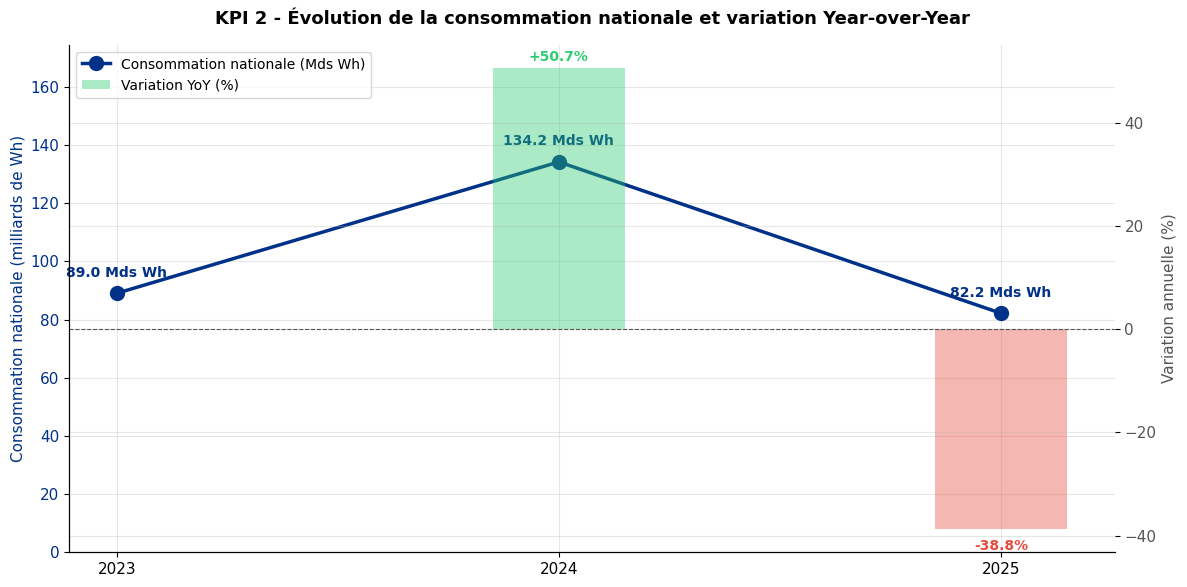

In [0]:
# Tout d'abord, je fais un tri chronologique (nécessaire pour que la courbe soit dans le bon sens)
df_tendance = df_tendance.sort_values("annee")

# Conversion de la consommation en milliards de Wh
df_tendance["conso_mds"] = df_tendance["conso_nationale_mwh"] / 1_000_000_000

fig, ax1 = plt.subplots(figsize=(12, 6))

#  Courbe principale : consommation nationale
# ax1 est l'axe gauche (consommation en milliards de Wh)
ax1.plot(
    df_tendance["annee"],    # Axe X : années
    df_tendance["conso_mds"],# Axe Y : consommation
    color=COULEUR_2023,      # Couleur de la courbe
    linewidth=2.5,           # Epaisseur de la ligne
    marker="o",              # Cercle a chaque point de donnée
    markersize=10,           # Taille des cercles
    label="Consommation nationale (Mds Wh)"
)

# Affichage des valeurs au-dessus de chaque point
for _, row in df_tendance.iterrows():
    ax1.annotate(
        f"{row['conso_mds']:.1f} Mds Wh",   # Texte à afficher
        xy=(row["annee"], row["conso_mds"]),  # Position du point
        xytext=(0, 12),                       # Decalage vertical du texte
        textcoords="offset points",           # Unite du decalage
        ha="center", fontsize=10, color=COULEUR_2023, fontweight="bold"
    )

ax1.set_ylabel("Consommation nationale (milliards de Wh)", fontsize=11, color=COULEUR_2023)
ax1.tick_params(axis="y", labelcolor=COULEUR_2023)
ax1.set_ylim(0, df_tendance["conso_mds"].max() * 1.3)  # Marge au-dessus pour les annotations

# Axe secondaire : variation YoY en pourcentage 

ax2 = ax1.twinx()   # twinx() cree un second axe Y partageant le meme axe X. ax2 est l'axe droit (variation en %)

# On filtre les lignes avec une variation disponible (pas null)
df_yoy = df_tendance.dropna(subset=["variation_yoy_pct"])

# Couleur conditionnelle : vert si hausse, rouge si baisse
couleurs_yoy = ["#2ECC71" if v > 0 else "#E74C3C" for v in df_yoy["variation_yoy_pct"]]

ax2.bar(
    df_yoy["annee"],             # Position sur l'axe X
    df_yoy["variation_yoy_pct"], # Hauteur des barres (%)
    width=0.3,                   # Barres étroites pour ne pas masquer la courbe
    color=couleurs_yoy,          # Vert ou rouge selon le signe
    alpha=0.4,                   # Transparente pour ne pas masquer la courbe principale
    label="Variation YoY (%)"
)

# Affichage des valeurs de variation sur chaque barre
for _, row in df_yoy.iterrows():
    signe = "+" if row["variation_yoy_pct"] > 0 else ""
    ax2.annotate(
        f"{signe}{row['variation_yoy_pct']:.1f}%",
        xy=(row["annee"], row["variation_yoy_pct"]),
        xytext=(0, 5 if row["variation_yoy_pct"] > 0 else -15),
        textcoords="offset points",
        ha="center", fontsize=10, fontweight="bold",
        color="#2ECC71" if row["variation_yoy_pct"] > 0 else "#E74C3C"
    )

ax2.set_ylabel("Variation annuelle (%)", fontsize=11, color="#555555")
ax2.tick_params(axis="y", labelcolor="#555555")
ax2.axhline(y=0, color="#555555", linewidth=0.8, linestyle="--")  # Ligne de reference a 0%

# Legendes combinées des deux axes
lignes1, labels1 = ax1.get_legend_handles_labels()
lignes2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lignes1 + lignes2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.set_xticks(df_tendance["annee"])
ax1.set_title(
    "KPI 2 - Évolution de la consommation nationale et variation Year-over-Year",
    fontsize=13, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()

### Interprétation du graphique

On observe un pic en 2024. J’ai identifié que cette hausse provient en partie de la granularité des données fournies par l’API et non d’une véritable évolution de la consommation. Sur un jeu de données complet et homogène l’analyse serait nettement plus fiable.


La courbe bleue représente ici la consommation nationale agrégée des 12 régions du périmètre inf36 (clients ≤ 36 kVA). 

Cette évolution ne s’explique pas uniquement par des facteurs climatiques ou comportementaux. Elle est aussi structurelle : l’API Enedis fournit environ 6 000 points de mesure en 2024 contre 4 500 en 2023 et 2025. Cela signifie que la granularité temporelle est plus fine en 2024 (découpage mensuel plus détaillé ou périmètre élargi). 

Une partie de la hausse observée est donc un artefact lié à la structure des données et non une augmentation réelle de la consommation.

Sur un jeu de données complet et homogène, les variations d’une année sur l’autre refléteraient davantage les tendances réelles : sobriété énergétique, développement du chauffage électrique, croissance du parc de véhicules électriques ou encore impact des températures hivernales.


## Visualisation KPI 3 - Répartition par catégorie de consommation

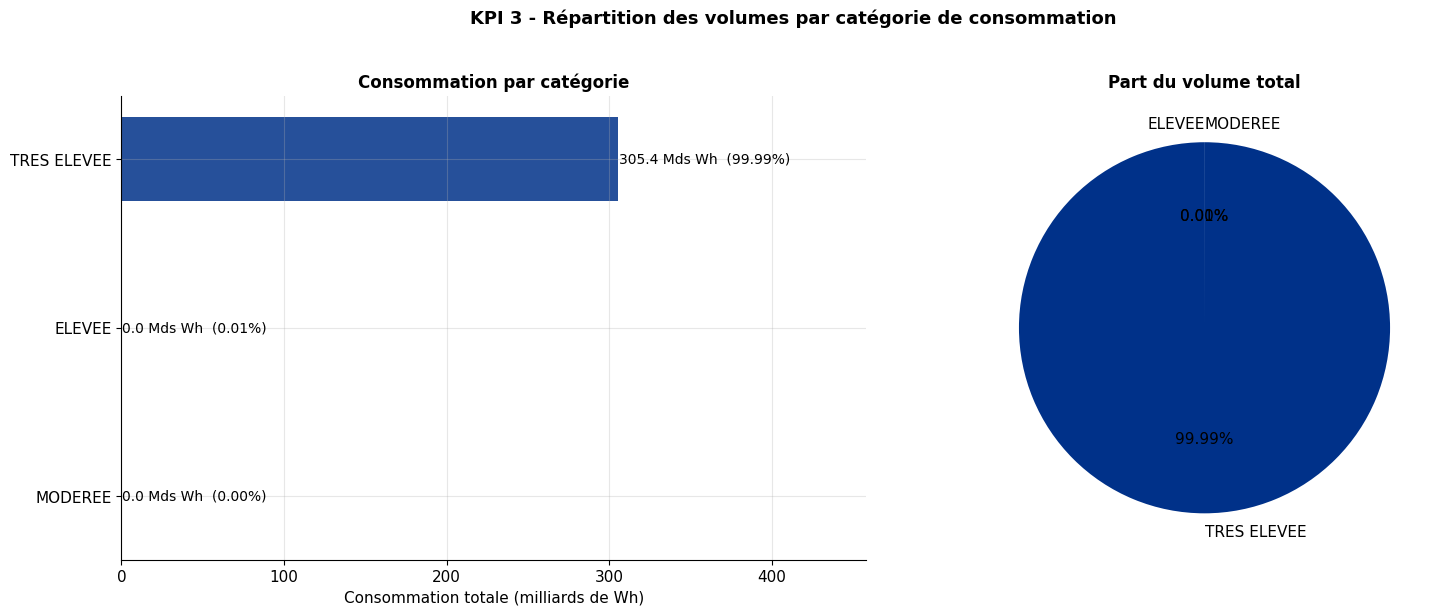

In [0]:
# On exclut la categorie INCONNU (valeurs nulles) pour ne pas fausser le graphique
df_cat_filtre = df_categorie[df_categorie["categorie_consommation"] != "INCONNU"].copy()

# Puis on fais un tri par consommation decroissante
df_cat_filtre = df_cat_filtre.sort_values("conso_totale_mwh", ascending=True)

# Conversion en milliards de Wh
df_cat_filtre["conso_mds"] = df_cat_filtre["conso_totale_mwh"] / 1_000_000_000

# Palette de couleurs par categorie
palette = {
    "TRES ELEVEE": COULEUR_2023,
    "ELEVEE":      COULEUR_2024,
    "MODEREE":     COULEUR_2025
}
couleurs_cat = [palette.get(c, "#AAAAAA") for c in df_cat_filtre["categorie_consommation"]]

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique gauche : barres horizontales ---
barres = ax_bar.barh(
    df_cat_filtre["categorie_consommation"],  # Axe Y : categories
    df_cat_filtre["conso_mds"],               # Axe X : consommation
    color=couleurs_cat,
    alpha=0.85,
    height=0.5
)

# Affichage des valeurs et pourcentages en bout de barre
for barre, (_, row) in zip(barres, df_cat_filtre.iterrows()):
    ax_bar.text(
        barre.get_width() + 0.5,     # Position X : juste apres la barre
        barre.get_y() + barre.get_height() / 2,  # Position Y : centre de la barre
        f"{row['conso_mds']:.1f} Mds Wh  ({row['pct_volume_total']:.2f}%)",
        va="center", fontsize=10
    )

ax_bar.set_xlabel("Consommation totale (milliards de Wh)", fontsize=11)
ax_bar.set_title("Consommation par catégorie", fontsize=12, fontweight="bold")
ax_bar.set_xlim(0, df_cat_filtre["conso_mds"].max() * 1.5)

# --- Graphique droit : camembert ---
ax_pie.pie(
    df_cat_filtre["pct_volume_total"],              # Valeurs (pourcentages)
    labels=df_cat_filtre["categorie_consommation"], # Etiquettes
    colors=couleurs_cat,                             # Couleurs
    autopct="%1.2f%%",                               # Affichage du % sur chaque part
    startangle=90,                                   # Rotation de depart
    pctdistance=0.6                                  # Distance du texte % par rapport au centre
)
ax_pie.set_title("Part du volume total", fontsize=12, fontweight="bold")

fig.suptitle(
    "KPI 3 - Répartition des volumes par catégorie de consommation",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.show()

### Interprétation du graphique

Le graphique confirme visuellement ce que les chiffres indiquaient : la catégorie TRES ELEVEE représente 99,99 % du volume total. Le camembert apparaît donc presque monochrome et les catégories ELEVEE et MODEREE deviennent pratiquement invisibles.

Cette distribution extrême n’est pas un bug mais la conséquence directe du niveau d’agrégation des données. L’UDF classe en TRES ELEVEE toute consommation dépassant un seuil défini pour des compteurs individuels alors qu’ici chaque ligne correspond à l’agrégat de milliers de compteurs à l’échelle d’une région. À ce niveau, les seuils initiaux ne sont plus adaptés, ce qui écrase la distribution.

Des analyses plus poussées pourrait permettraient d’obtenir une répartition plus équilibrée par exemple en recalibrant les seuils de l'UDF sur des valeurs regionales réelles ou en appliquant la catégorisation au niveau du compteur individuel avant agregation (c’est‑à‑dire au niveau de chaque compteur individuel dans les données brutes).



## Visualisation KPI 4 - Classement des régions

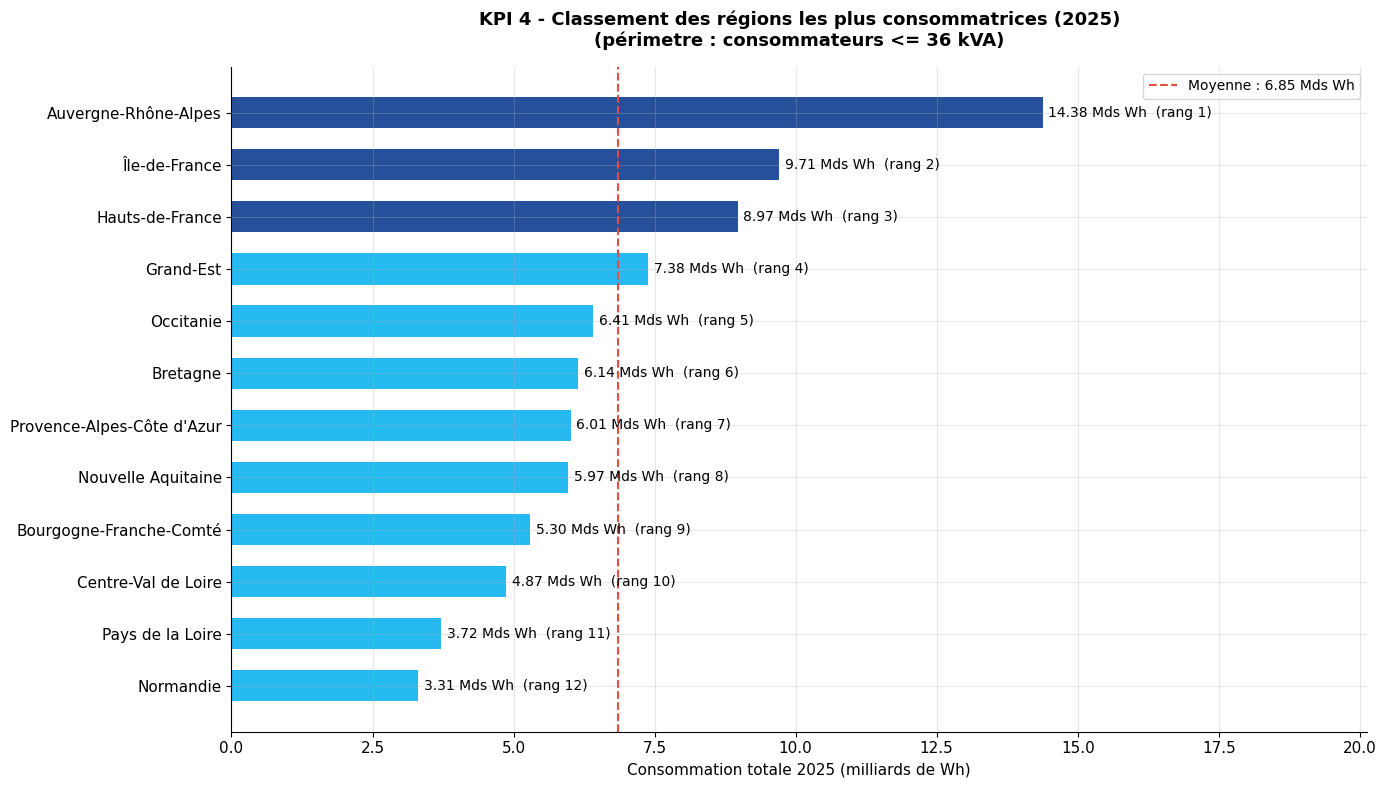

In [0]:
# Tri par consommation croissante pour que la region n°1 soit en haut du graphique
df_top_sorted = df_top.sort_values("conso_totale_mwh", ascending=True)

# Conversion en milliards de Wh
df_top_sorted["conso_mds"] = df_top_sorted["conso_totale_mwh"] / 1_000_000_000

# Couleur variable selon le classement : les 3 premières en bleu foncé et les autres en bleu clair
couleurs_top = [
    COULEUR_2023 if rang <= 3 else COULEUR_2025
    for rang in df_top_sorted["classement"]
]

fig, ax = plt.subplots(figsize=(14, 8))

barres = ax.barh(
    df_top_sorted["region"],      # Axe Y : noms des régions
    df_top_sorted["conso_mds"],   # Axe X : consommation en Mds Wh
    color=couleurs_top,
    alpha=0.85,
    height=0.6
)

# Affichage des valeurs et du rang en bout de barre
for barre, (_, row) in zip(barres, df_top_sorted.iterrows()):
    ax.text(
        barre.get_width() + 0.1,
        barre.get_y() + barre.get_height() / 2,
        f"{row['conso_mds']:.2f} Mds Wh  (rang {int(row['classement'])})",
        va="center", fontsize=10
    )

ax.set_xlabel("Consommation totale 2025 (milliards de Wh)", fontsize=11)
ax.set_title(
    "KPI 4 - Classement des régions les plus consommatrices (2025)\n(périmetre : consommateurs <= 36 kVA)",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlim(0, df_top_sorted["conso_mds"].max() * 1.4)

# Ligne verticale de réference : consommation moyenne
moyenne = df_top_sorted["conso_mds"].mean()
ax.axvline(
    x=moyenne,
    color="#E74C3C",
    linewidth=1.5,
    linestyle="--",
    label=f"Moyenne : {moyenne:.2f} Mds Wh"
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


### Interprétation du graphique


Le classement 2025 place Auvergne-Rhone-Alpes largement en tete avec 14.38 Mds Wh, soit plus du double de l'Ile-de-France (rang 2, 9.71 Mds Wh). Les 3 premieres regions
(bleu fonce) consomment à elles seules plus que les 9 regions suivantes reunies.

La ligne rouge pointillée représente la moyenne nationale à 6.85 Mds Wh. On constate que seulement 4 regions depassent cette moyenne (Auvergne-Rhone-Alpes, Ile-de-France,
Hauts-de-France, Grand-Est) ce qui illustre une distribution asymetrique : quelques grandes regions industrielles tirent la moyenne vers le haut.

Grand-Est (rang 4) et Occitanie (rang 5) se situent de part et d'autre de la moyenne formant un groupe de régions intermediaires très proches en termes de consommation
(entre 6 et 8 Mds Wh). Les régions du bas du classement (Normandie, Pays de la Loire) consomment environ 4 fois moins qu'Auvergne-Rhone-Alpes ce qui traduit des differences
de tissu industriel et non uniquement de population.
